In [1]:
d_vocab = 512
d_embedding = 32
d_model = 512
n_layers = 2
context_len = 100

In [2]:
%env GLOG_minloglevel=2
from tokenizer import TokenizerBPE

tokenizer = TokenizerBPE(name=str(d_vocab), vocab_size=d_vocab)

env: GLOG_minloglevel=2


In [3]:
from pathlib import Path

with open(Path(".") / "data" / "pixar.txt") as pixar_file:
    lines = pixar_file.readlines()

In [4]:
import random

random.shuffle(lines)

a = int(0.9 * len(lines))
train_lines = lines[:a]
test_lines = lines[a:]

In [5]:
from dataloader import PixarDataset

train_dataset = PixarDataset(
    train_lines,
    context_len=context_len,
    begin_id=1,
    end_id=2,
    pad_id=3,
    tokenizer=tokenizer,
)

test_dataset = PixarDataset(
    test_lines,
    context_len=context_len,
    begin_id=1,
    end_id=2,
    pad_id=3,
    tokenizer=tokenizer,
)

In [6]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
from model import PixarModel

pixar_model = PixarModel(
    d_vacab=d_vocab,
    d_embedding=d_embedding,
    d_model=d_model,
    n_layers=n_layers,
)

In [8]:
from functools import partial

from dataloader import collate_fn
from torch.utils.data import DataLoader

batch_size = 512

collate = partial(collate_fn, pad_id=3)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, collate_fn=collate)

In [9]:
from torch.optim.adamw import AdamW

optimizer = AdamW(
    pixar_model.parameters(),
    lr=0.001,
)

In [11]:
import torch
import torch.nn.functional as F

pad_id = 3
epochs = 10
eval_every_n = 2
batch_size = 512

pixar_model = pixar_model.to(device)

train_losses = []
valid_losses = []


@torch.no_grad()
def evaluate(model, loader, device, pad_id):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for data in loader:
        data = data.to(device)
        x = data[:, :-1]
        y = data[:, 1:]
        logits = model(x)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1),
            ignore_index=pad_id,
        )
        total_loss += loss.item()
        n_batches += 1
    model.train()
    return total_loss / max(n_batches, 1)


for epoch in range(epochs):
    pixar_model.train()
    epoch_loss, n_batches = 0.0, 0

    for data in train_loader:
        data = data.to(device)
        x = data[:, :-1]
        y = data[:, 1:]

        logits = pixar_model(x)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1),
            ignore_index=pad_id,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_loss / max(n_batches, 1)
    train_losses.append((epoch, avg_train_loss))

    if epoch % eval_every_n == 0:
        avg_valid_loss = evaluate(pixar_model, test_loader, device, pad_id)
        valid_losses.append((epoch, avg_valid_loss))
        print(f"epoch {epoch}: train_loss={avg_train_loss:.4f} valid_loss={avg_valid_loss:.4f}")
    else:
        print(f"epoch {epoch}: train_loss={avg_train_loss:.4f}")

epoch 0: train_loss=2.1292 valid_loss=1.9176
epoch 1: train_loss=1.8016
epoch 2: train_loss=1.6712 valid_loss=1.7589
epoch 3: train_loss=1.5787
epoch 4: train_loss=1.5054 valid_loss=1.7335
epoch 5: train_loss=1.4402
epoch 6: train_loss=1.3873 valid_loss=1.7456
epoch 7: train_loss=1.3362
epoch 8: train_loss=1.2947 valid_loss=1.7812
epoch 9: train_loss=1.2580


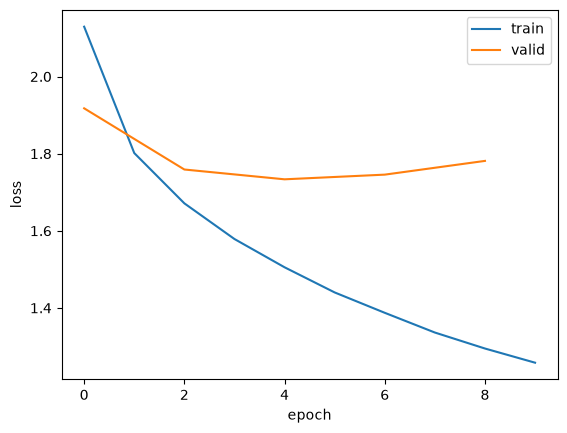

In [16]:
import matplotlib.pyplot as plt

train_x = [e for e, _ in train_losses]
train_y = [l for _, l in train_losses]
valid_x = [e for e, _ in valid_losses]
valid_y = [l for _, l in valid_losses]

plt.plot(train_x, train_y, label="train")
plt.plot(valid_x, valid_y, label="valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [17]:
torch.save(pixar_model.state_dict(), "pixar_model.pt")

In [18]:
@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt: str,
    begin_id: int,
    end_id: int,
    max_len: int,
    device: str,
    stop_at_eos: bool = True,
) -> str:
    model.eval()

    tokens = tokenizer.encode(prompt) if prompt else []
    seq = [begin_id] + tokens

    x = torch.tensor([seq], device=device)

    for _ in range(max_len - len(seq)):
        logits = model(x)
        next_token_logits = logits[0, -1]
        next_token = next_token_logits.argmax(dim=-1).item()

        x = torch.cat([x, torch.tensor([[next_token]], device=device)], dim=1)

        if stop_at_eos and next_token == end_id:
            break

    ids = x[0, 1:].tolist()
    if ids and ids[-1] == end_id:
        ids = ids[:-1]

    model.train()
    return tokenizer.decode(ids)

In [19]:
text = generate(
    pixar_model, tokenizer,
    prompt="Once upon a time",
    begin_id=1, end_id=2,
    max_len=context_len,
    device=device,
)
print(text)

Once upon a time together, they stand back. 



In [24]:
def generate_long_text(model, tokenizer, begin_id, end_id, context_len, device, total_length, output_path, seed_prompt=""):
    full_text = seed_prompt
    current_prompt = seed_prompt

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(seed_prompt)

        iteration = 0
        while len(full_text) < total_length:
            iteration += 1
            chunk = generate(
                model, tokenizer, prompt=current_prompt,
                begin_id=begin_id, end_id=end_id, max_len=context_len,
                device=device, stop_at_eos=True,
            )
            print(f"[iter {iteration}] chunk={chunk!r}")   # DEBUG

            new_content = chunk.removeprefix(current_prompt)
            print(f"[iter {iteration}] new_content={new_content!r}")   # DEBUG

            f.write(new_content + "\n")
            full_text += new_content
            current_prompt = new_content[-50:]

    print(f"Zapisano {len(full_text)} znaków do {output_path}")

In [ ]:
generate_long_text(
    pixar_model, tokenizer,
    begin_id=1, end_id=2,
    context_len=context_len,
    device=device,
    total_length=5000,
    output_path="generated_pixar.txt",
    seed_prompt="A young hero discovers",
)

[iter 1] chunk='A young hero discovers and gives a picture of an\n'
[iter 1] new_content=' and gives a picture of an\n'
[iter 2] chunk=' and gives a picture of an\n'
[iter 2] new_content=''
[iter 3] chunk='\n'
[iter 3] new_content='\n'
[iter 4] chunk='\n'
[iter 4] new_content=''
[iter 5] chunk='\n'
[iter 5] new_content='\n'
[iter 6] chunk='\n'
[iter 6] new_content=''
[iter 7] chunk='\n'
[iter 7] new_content='\n'
[iter 8] chunk='\n'
[iter 8] new_content=''
[iter 9] chunk='\n'
[iter 9] new_content='\n'
[iter 10] chunk='\n'
[iter 10] new_content=''
[iter 11] chunk='\n'
[iter 11] new_content='\n'
[iter 12] chunk='\n'
[iter 12] new_content=''
[iter 13] chunk='\n'
[iter 13] new_content='\n'
[iter 14] chunk='\n'
[iter 14] new_content=''
[iter 15] chunk='\n'
[iter 15] new_content='\n'
[iter 16] chunk='\n'
[iter 16] new_content=''
[iter 17] chunk='\n'
[iter 17] new_content='\n'
[iter 18] chunk='\n'
[iter 18] new_content=''
[iter 19] chunk='\n'
[iter 19] new_content='\n'
[iter 20] chunk='\n'
[it